Rank-based Fusion

In [ ]:
import json
import ir_datasets
import ir_measures
from ir_measures import *
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import matplotlib.pyplot as plt
import numpy as np

def fuse(runs, weights):
    fused_run = {}
    qids = set()
    for run in runs:
        qids.update(run.keys())
    for qid in qids:
        fused_run[qid] = {}
        for run in runs:
            for doc in run[qid]['docs']:
                if doc not in fused_run[qid]:
                    score = 0
                    for temp_run, weight in zip(runs, weights):
                        if doc in temp_run[qid]['docs']:
                            min_score = temp_run[qid]['min_score']
                            max_score = temp_run[qid]['max_score']
                            denominator = max_score - min_score
                            denominator = max(denominator, 1e-9)
                            score += weight * ((temp_run[qid]['docs'][doc] - min_score) / denominator)
                        else:
                            score += 0
                    fused_run[qid][doc] = score
    return fused_run

def convert2fusion(run_dict):
    run = {}
    for qid in run_dict:
        if qid not in run:
            run[qid] = {'docs': {}, 'max_score': None, 'min_score': None}
        scores = list(run_dict[qid].values())
        # print( scores )
        run[qid]['max_score'] = max(scores)
        run[qid]['min_score'] = min(scores)
        for docid, score in run_dict[qid].items():
            run[qid]['docs'][docid] = score
    return run

def rank_fusion(top_old_indices, top_new_indices, k=3, constant=60):
    unique_docs = set(top_old_indices) | set(top_new_indices)
    fused_scores = {doc: 0 for doc in unique_docs}
    
    for rank, doc in enumerate(top_old_indices, 1):
        fused_scores[doc] += 1 / (rank + constant)
    
    for rank, doc in enumerate(top_new_indices, 1):
        fused_scores[doc] += 1 / (rank + constant)
    
    # Sort by fused score descending
    fused_ranked = sorted(fused_scores, key=fused_scores.get, reverse=True)[:k]
    return fused_ranked

def read_run(run_file_path):
    with open(run_file_path, 'r') as f:
        run = json.load(f)
    return run

old_query_model_name = "sp_co_selfdistil"
old_doc_model_name = "sp_co_selfdistil"
new_query_model_name = "sp_v3"
new_doc_model_name = "sp_v3"

dir = "/ivi/ilps/personal/jkang1/jf/lsr-bc/results/results_normal"
datasets = {
    "TRECCOVID": "trec-covid",
    "NFCorpus": "nfcorpus/test",
    "NQ": "nq",
    "HotpotQA": "hotpotqa/test",
    "FiQA2018": "fiqa/test",
    "ArguAna": "arguana",
    "Touche2020": "webis-touche2020",
    "CQADupstackRetrieval": "cqadupstack",
    "QuoraRetrieval": "quora/test",
    "DBPedia": "dbpedia-entity/test",
    "SCIDOCS": "scidocs",
    "FEVER": "fever/test",
    "ClimateFEVER": "climate-fever",
    "SciFact": "scifact/test",
    "MSMARCO": "msmarco/dev",
}

alpha = 0.5
rank_based_fusion = {}
for path_data_name, beir_data_name in datasets.items():
    if path_data_name == "CQADupstackRetrieval": 
        cqadupstack_scors = []
        for CQADupstack_name in ["AndroidRetrieval", "EnglishRetrieval", "GamingRetrieval", "GisRetrieval", "MathematicaRetrieval", "PhysicsRetrieval", "Programmers-VN", "StatsRetrieval", "TexRetrieval", "UnixRetrieval", "WebmastersRetrieval", "WordpressRetrieval"]:
            old_query_model_old_doc_model_path = f"{dir}/q_{old_query_model_name}_d_{old_doc_model_name}/CQADupstack{CQADupstack_name}_default_predictions.json"
            new_query_model_new_doc_model_path = f"{dir}/q_{new_query_model_name}_d_{new_doc_model_name}/CQADupstack{CQADupstack_name}_default_predictions.json"
            new_query_model_old_doc_model_path = f"{dir}/q_{new_query_model_name}_d_{old_doc_model_name}/CQADupstack{CQADupstack_name}_default_predictions.json"

            old_query_model_old_doc_model_run_res = read_run(old_query_model_old_doc_model_path)
            new_query_model_new_doc_model_run_res = read_run(new_query_model_new_doc_model_path)
            new_query_model_old_doc_model_run_res = read_run(new_query_model_old_doc_model_path)

            fusion_run_res = fuse(
                runs=[convert2fusion(old_query_model_old_doc_model_run_res), convert2fusion(new_query_model_old_doc_model_run_res)],
                weights=[alpha, (1 - alpha)],
            )
            qrel_name = CQADupstack_name.replace("Retrieval", "").replace("-VN", "").lower()
            qrels = ir_datasets.load(f'beir/cqadupstack/{qrel_name}').qrels
            fusion_run_res = ir_measures.calc_aggregate([nDCG@10], qrels, fusion_run_res)
            cqadupstack_scors.append(fusion_run_res[nDCG@10])
        # print("CQADupstack Average nDCG@10:", np.mean(cqadupstack_scors))
        print(np.mean(cqadupstack_scors))
        continue
        
    old_query_model_old_doc_model_path = f"{dir}/q_{old_query_model_name}_d_{old_doc_model_name}/{path_data_name}_default_predictions.json"
    new_query_model_new_doc_model_path = f"{dir}/q_{new_query_model_name}_d_{new_doc_model_name}/{path_data_name}_default_predictions.json"
    new_query_model_old_doc_model_path = f"{dir}/q_{new_query_model_name}_d_{old_doc_model_name}/{path_data_name}_default_predictions.json"

    old_query_model_old_doc_model_run_res = read_run(old_query_model_old_doc_model_path)
    new_query_model_new_doc_model_run_res = read_run(new_query_model_new_doc_model_path)
    new_query_model_old_doc_model_run_res = read_run(new_query_model_old_doc_model_path)

    fusion_run_res = fuse(
        runs=[convert2fusion(old_query_model_old_doc_model_run_res), convert2fusion(new_query_model_old_doc_model_run_res)],
        weights=[alpha, (1 - alpha)],
    )
    qrels = ir_datasets.load(f'beir/{beir_data_name}').qrels
    # old_query_model_old_doc_model_metrics = ir_measures.calc_aggregate([nDCG@10], qrels, old_query_model_old_doc_model_run_res)
    # new_query_model_new_doc_model_metrics = ir_measures.calc_aggregate([nDCG@10], qrels, new_query_model_new_doc_model_run_res)
    # new_query_model_old_doc_model_metrics = ir_measures.calc_aggregate([nDCG@10], qrels, new_query_model_old_doc_model_run_res)
    fusion_run_res = ir_measures.calc_aggregate([nDCG@10], qrels, fusion_run_res)
    # print("Dataset:", path_data_name)
    # print(old_query_model_old_doc_model_metrics, "Old Query Model & Old Doc Model Results Path")
    # print(new_query_model_new_doc_model_metrics, "New Query Model & New Doc Model Results Path")
    # print(new_query_model_old_doc_model_metrics, "New Query Model & Old Doc Model Results Path")
    # print(fusion_run_res, "Fusion Results Path")
    print(fusion_run_res[nDCG@10])
    
    # print("\n")
    # rank_based_fusion[path_data_name] = {"old_query_model_old_doc_model": old_query_model_old_doc_model_metrics[nDCG@10],
    #                                     "new_query_model_new_doc_model": new_query_model_new_doc_model_metrics[nDCG@10],
    #                                     "new_query_model_old_doc_model": new_query_model_old_doc_model_metrics[nDCG@10],
    #                                     "fusion": fusion_run_res[nDCG@10]}

0.733256642395562
0.3578505041484731
0.5464084721250451


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7ffa54178910>>
Traceback (most recent call last):
  File "/ivi/ilps/personal/jkang1/anaconda3/envs/lsrbc/lib/python3.9/site-packages/ipykernel/ipkernel.py", line 781, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


In [ ]:
# Compute average nDCG@10 across datasets for each model and add as an 'Average' entry
if len(rank_based_fusion) > 0:
    metric_keys = ["old_query_model_old_doc_model", "new_query_model_new_doc_model", "new_query_model_old_doc_model", "fusion"]
    sums = {k: 0.0 for k in metric_keys}
    count = 0
    for ds_name, vals in list(rank_based_fusion.items()):
        # skip if this is already an Average entry or if the value is not a dict
        if ds_name == 'Average' or not isinstance(vals, dict):
            continue
        # ensure all keys present
        if not all(k in vals for k in metric_keys):
            continue
        for k in metric_keys:
            sums[k] += vals[k]
        count += 1
    if count > 0:
        avg_vals = {k: (sums[k] / count) for k in metric_keys}
        rank_based_fusion['Average'] = avg_vals
rank_based_fusion

{'TRECCOVID': {'old_query_model_old_doc_model': 0.5513248010337485,
  'new_query_model_new_doc_model': 0.7322537315687433,
  'new_query_model_old_doc_model': 0.5816236884586425,
  'fusion': 0.5765175074515823},
 'NFCorpus': {'old_query_model_old_doc_model': 0.30937191104593215,
  'new_query_model_new_doc_model': 0.3634638320261206,
  'new_query_model_old_doc_model': 0.3224326303622513,
  'fusion': 0.3277873603999181},
 'NQ': {'old_query_model_old_doc_model': 0.38857659173501585,
  'new_query_model_new_doc_model': 0.5871713098378171,
  'new_query_model_old_doc_model': 0.4011990691426544,
  'fusion': 0.42389811524926824},
 'HotpotQA': {'old_query_model_old_doc_model': 0.5503620595546987,
  'new_query_model_new_doc_model': 0.6921824241123574,
  'new_query_model_old_doc_model': 0.6011519935548182,
  'fusion': 0.5994431129265972},
 'FiQA2018': {'old_query_model_old_doc_model': 0.23777341611808378,
  'new_query_model_new_doc_model': 0.3801381502160503,
  'new_query_model_old_doc_model': 0.23

None


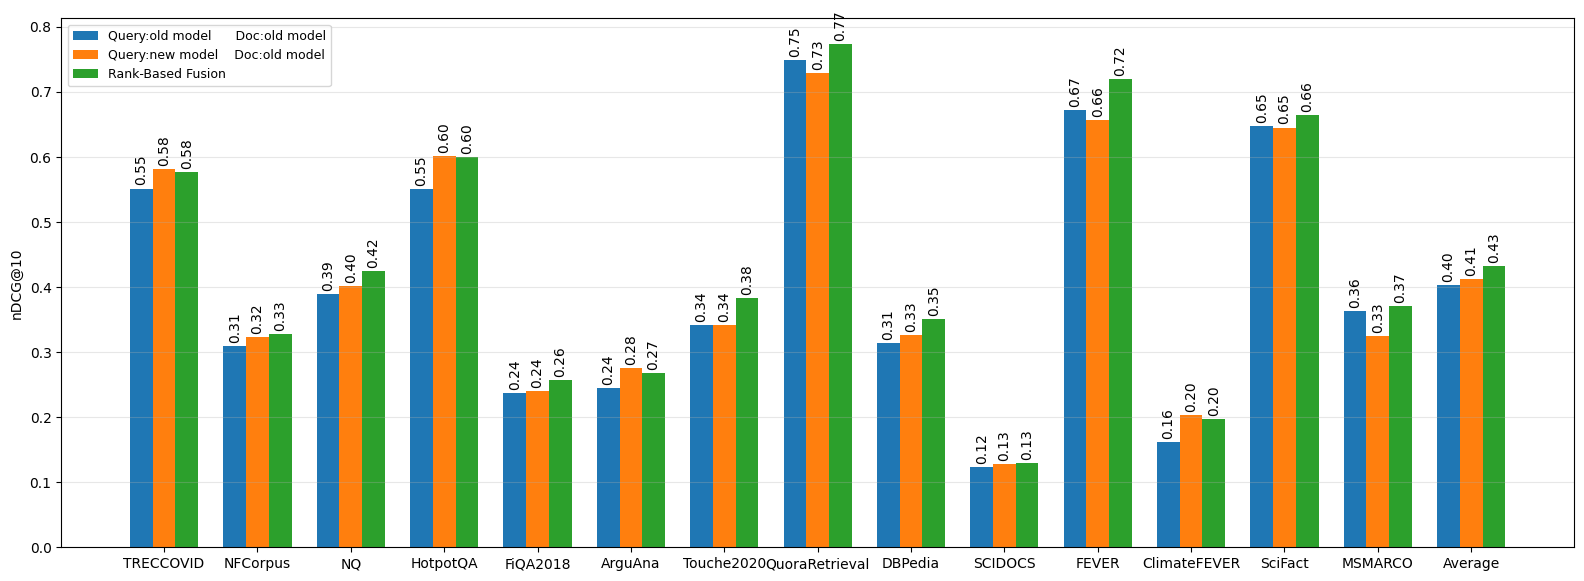

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

old_query_model_name = "sp_v3_doc"
old_doc_model_name = "sp_v3_doc"
new_query_model_name = "sp_v3"
new_doc_model_name = "sp_v3"

# Data
data = rank_based_fusion

label_map = {
    f'old_query_model_old_doc_model': f'Query:old model      Doc:old model',
    # f'new_query_model_new_doc_model': f'Query: {new_query_model_name} Doc: {new_doc_model_name}',
    f'new_query_model_old_doc_model': f'Query:new model    Doc:old model',
    f'fusion': 'Rank-Based Fusion',
}

datasets = list(data.keys())
categories = list(next(iter(data.values())).keys())
print(categories.remove('new_query_model_new_doc_model'))
num_cats = len(categories)

# Bar placement
bar_width = 0.18
gap = 0.2  # space between dataset groups
x = np.arange(len(datasets)) * (num_cats * bar_width + gap)

# --- Plot ---
fig, ax = plt.subplots(figsize=(16,6))
plt.rcParams.update({'font.size': 12})

for i, category in enumerate(categories):
    if category == 'new_query_model_new_doc_model':
        continue
    values = [data[ds][category] for ds in datasets]
    ax.bar(x + i*bar_width, values, width=bar_width, label=label_map[category])

# Axis setup
ax.set_ylabel('nDCG@10')
# ax.set_title(f'{{old_query_model_name}} & {{new_query_model_name}}')

# Center dataset labels under groups
ax.set_xticks(x + (num_cats - 1) * bar_width / 2)
ax.set_xticklabels(datasets)

# Grid & legend
ax.grid(axis='y', alpha=0.3)
ax.legend(loc='upper left', bbox_to_anchor=(0, 1), fontsize=9)

# Add value labels on top of each bar
for rect in ax.patches:
    height = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2, height + 0.005,
            f'{height:.2f}', ha='center', va='bottom', fontsize=10, rotation=90)

plt.tight_layout()
plt.show()
plt.savefig('rank_based_fusion_comparison.png', dpi=300)


Term-based Fusion

In [ ]:
import json
import os
import ir_datasets
import ir_measures
from ir_measures import *
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def read_run(run_file_path):
    with open(run_file_path, 'r') as f:
        run = json.load(f)
    return run

old_query_model_name = "sp_v3_lexical"
old_doc_model_name = "sp_v3_lexical"
new_query_model_name = "sp_v3"
new_doc_model_name = "sp_v3"

datasets = {
    "TRECCOVID": "trec-covid",
    "NFCorpus": "nfcorpus/test",
    "NQ": "nq",
    "HotpotQA": "hotpotqa/test",
    "FiQA2018": "fiqa/test",
    "ArguAna": "arguana",
    "Touche2020": "webis-touche2020",
    "CQADupstackRetrieval": "cqadupstack",
    "QuoraRetrieval": "quora/test",
    "DBPedia": "dbpedia-entity/test",
    "SCIDOCS": "scidocs",
    "FEVER": "fever/test",
    "ClimateFEVER": "climate-fever",
    "SciFact": "scifact/test",
    "MSMARCO": "msmarco/dev",
}

original_dir = "/ivi/ilps/personal/jkang1/jf/lsr-bc/results/results_normal"
fusion_dir = "/ivi/ilps/personal/jkang1/jf/lsr-bc/fusion_results"

term_based_fusion = {}
for path_data_name, beir_data_name in datasets.items():
    result_path = [item for item in os.listdir( f"{original_dir}/q_{old_doc_model_name}_d_{old_doc_model_name}/") if item.startswith("jingfen")][0]
    old_query_model_old_doc_model_path = f"{original_dir}/q_{old_doc_model_name}_d_{old_doc_model_name}/{result_path}/v1/{path_data_name}.json"
    new_query_model_old_doc_model_path = f"{original_dir}/q_{new_query_model_name}_d_{old_doc_model_name}/{result_path}/v1/{path_data_name}.json"

    # with open(old_query_model_old_doc_model_path, 'r') as f:
    #     result = json.load(f)
    #     if beir_data_name == "MSMARCO":
    #         res_ndcg_at_10 = result['scores']['dev'][0]['ndcg_at_10']
    #     else:
    #         res_ndcg_at_10 = result['scores']['test'][0]['ndcg_at_10']
    #     print(f"{res_ndcg_at_10}")

    # for fusion_type in [1,2,3,4]:
    for fusion_type in [2]:
        fusion_result_path = [item for item in os.listdir( f"{fusion_dir}/new_{new_query_model_name}_old_{old_doc_model_name}_fusion_type_{fusion_type}/") if item.startswith("jingfen")][0]
        fusion_new_query_model_old_doc_model_path = f"{fusion_dir}/new_{new_query_model_name}_old_{old_doc_model_name}_fusion_type_{fusion_type}/{fusion_result_path}/v1/{path_data_name}.json"
        with open(fusion_new_query_model_old_doc_model_path, 'r') as f:
            result = json.load(f)
            if path_data_name == "MSMARCO":
                res_ndcg_at_10 = result['scores']['dev'][0]['ndcg_at_10']
            else:
                res_ndcg_at_10 = result['scores']['test'][0]['ndcg_at_10']
            print(f"{res_ndcg_at_10}")

0.65165
0.35492
0.57354
0.68717
0.37152
0.50146
0.22281
0.323826
0.72091
0.44415
0.15916
0.77882
0.24152
0.72676
0.45278


In [ ]:
import json
import ir_datasets
import ir_measures
from ir_measures import *
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def read_run(run_file_path):
    with open(run_file_path, 'r') as f:
        run = json.load(f)
    return run

old_query_model_name = "sp_v3_lexical"
old_doc_model_name = "sp_v3_lexical"
new_query_model_name = "sp_v3"
new_doc_model_name = "sp_v3"

datasets = {
    "TRECCOVID": "trec-covid",
    "NFCorpus": "nfcorpus/test",
    "NQ": "nq",
    "HotpotQA": "hotpotqa/test",
    "FiQA2018": "fiqa/test",
    "ArguAna": "arguana",
    "Touche2020": "webis-touche2020",
    "CQADupstackRetrieval": "cqadupstack",
    "QuoraRetrieval": "quora/test",
    "DBPedia": "dbpedia-entity/test",
    "SCIDOCS": "scidocs",
    "FEVER": "fever/test",
    "ClimateFEVER": "climate-fever",
    "SciFact": "scifact/test",
    "MSMARCO": "msmarco/dev",
}

original_dir = "/ivi/ilps/personal/jkang1/jf/lsr-bc/results/results_normal"
fusion_dir = "/ivi/ilps/personal/jkang1/jf/lsr-bc/fusion_results"

term_based_fusion = {}
for path_data_name, beir_data_name in datasets.items():
    if path_data_name == "CQADupstackRetrieval": continue
    qrels = ir_datasets.load(f'beir/{beir_data_name}').qrels
    print(beir_data_name)
    old_query_model_old_doc_model_path = f"{original_dir}/q_{old_doc_model_name}_d_{old_doc_model_name}/{path_data_name}_default_predictions.json"
    old_query_model_old_doc_model_run_res = read_run(old_query_model_old_doc_model_path)
    old_query_model_old_doc_model_metrics = ir_measures.calc_aggregate([nDCG@10], qrels, old_query_model_old_doc_model_run_res)

    new_query_model_old_doc_model_path = f"{original_dir}/q_{new_query_model_name}_d_{old_doc_model_name}/{path_data_name}_default_predictions.json"
    new_query_model_old_doc_model_run_res = read_run(new_query_model_old_doc_model_path)
    new_query_model_old_doc_model_metrics = ir_measures.calc_aggregate([nDCG@10], qrels, new_query_model_old_doc_model_run_res)

    fusion_new_query_model_old_doc_model_path_type1 = f"{fusion_dir}/new_{new_query_model_name}_old_{old_doc_model_name}_fusion_type_1/{path_data_name}_default_predictions.json"
    fusion_new_query_model_old_doc_model_run_res_type1 = read_run(fusion_new_query_model_old_doc_model_path_type1)
    fusion_new_query_model_old_doc_model_metrics_type1 = ir_measures.calc_aggregate([nDCG@10], qrels, fusion_new_query_model_old_doc_model_run_res_type1)

    fusion_new_query_model_old_doc_model_path_type2 = f"{fusion_dir}/new_{new_query_model_name}_old_{old_doc_model_name}_fusion_type_2/{path_data_name}_default_predictions.json"
    fusion_new_query_model_old_doc_model_run_res_type2 = read_run(fusion_new_query_model_old_doc_model_path_type2)
    fusion_new_query_model_old_doc_model_metrics_type2 = ir_measures.calc_aggregate([nDCG@10], qrels, fusion_new_query_model_old_doc_model_run_res_type2)

    fusion_new_query_model_old_doc_model_path_type3 = f"{fusion_dir}/new_{new_query_model_name}_old_{old_doc_model_name}_fusion_type_3/{path_data_name}_default_predictions.json"
    fusion_new_query_model_old_doc_model_run_res_type3 = read_run(fusion_new_query_model_old_doc_model_path_type3)
    fusion_new_query_model_old_doc_model_metrics_type3 = ir_measures.calc_aggregate([nDCG@10], qrels, fusion_new_query_model_old_doc_model_run_res_type3)

    fusion_new_query_model_old_doc_model_path_type4 = f"{fusion_dir}/new_{new_query_model_name}_old_{old_doc_model_name}_fusion_type_4/{path_data_name}_default_predictions.json"
    fusion_new_query_model_old_doc_model_run_res_type4 = read_run(fusion_new_query_model_old_doc_model_path_type4)
    fusion_new_query_model_old_doc_model_metrics_type4 = ir_measures.calc_aggregate([nDCG@10], qrels, fusion_new_query_model_old_doc_model_run_res_type4)

    print(old_query_model_old_doc_model_metrics, "Old Query Model & Old Doc Model Results Path:")
    print(new_query_model_old_doc_model_metrics, "New Query Model & Old Doc Model Results Path:")
    print(fusion_new_query_model_old_doc_model_metrics_type1, "Type 1 Fusion: New Query Model & Old Doc Model Results Path")
    print(fusion_new_query_model_old_doc_model_metrics_type2, "Type 2 Fusion: New Query Model & Old Doc Model Results Path")
    print(fusion_new_query_model_old_doc_model_metrics_type3, "Type 3 Fusion: New Query Model & Old Doc Model Results Path")
    print(fusion_new_query_model_old_doc_model_metrics_type4, "Type 4 Fusion: New Query Model & Old Doc Model Results Path")
    print("\n")
    term_based_fusion[path_data_name] = {"old_query_model_old_doc_model": old_query_model_old_doc_model_metrics[nDCG@10],
                                         "new_query_model_old_doc_model": new_query_model_old_doc_model_metrics[nDCG@10],
                                         "fusion_type_1": fusion_new_query_model_old_doc_model_metrics_type1[nDCG@10],
                                         "fusion_type_2": fusion_new_query_model_old_doc_model_metrics_type2[nDCG@10],
                                         "fusion_type_3": fusion_new_query_model_old_doc_model_metrics_type3[nDCG@10],
                                         "fusion_type_4": fusion_new_query_model_old_doc_model_metrics_type4[nDCG@10]
                                         }


trec-covid
{nDCG@10: 0.6317410475560561} Old Query Model & Old Doc Model Results Path:
{nDCG@10: 0.6436946469659649} New Query Model & Old Doc Model Results Path:
{nDCG@10: 0.6438903163082241} Type 1 Fusion: New Query Model & Old Doc Model Results Path
{nDCG@10: 0.6516488455009246} Type 2 Fusion: New Query Model & Old Doc Model Results Path
{nDCG@10: 0.6443104545634536} Type 3 Fusion: New Query Model & Old Doc Model Results Path
{nDCG@10: 0.6398519429358905} Type 4 Fusion: New Query Model & Old Doc Model Results Path


nfcorpus/test
{nDCG@10: 0.35249702189781046} Old Query Model & Old Doc Model Results Path:
{nDCG@10: 0.35347991533788786} New Query Model & Old Doc Model Results Path:
{nDCG@10: 0.35045149016536753} Type 1 Fusion: New Query Model & Old Doc Model Results Path
{nDCG@10: 0.3549185367577237} Type 2 Fusion: New Query Model & Old Doc Model Results Path
{nDCG@10: 0.3535281992283069} Type 3 Fusion: New Query Model & Old Doc Model Results Path
{nDCG@10: 0.3506515676876542} Type 4

FileNotFoundError: [Errno 2] No such file or directory: '/ivi/ilps/personal/jkang1/jf/lsr-bc/fusion_results/new_sp_v3_old_sp_v3_lexical_fusion_type_1/MSMARCO_default_predictions.json'

In [ ]:
# Compute average nDCG@10 across datasets for each model and add as an 'Average' entry
if len(term_based_fusion) > 0:
    metric_keys = ["old_query_model_old_doc_model", "new_query_model_old_doc_model", "fusion_type_2"]
    sums = {k: 0.0 for k in metric_keys}
    count = 0
    for ds_name, vals in list(term_based_fusion.items()):
        # skip if this is already an Average entry or if the value is not a dict
        if ds_name == 'Average' or not isinstance(vals, dict):
            continue
        # ensure all keys present
        if not all(k in vals for k in metric_keys):
            continue
        for k in metric_keys:
            sums[k] += vals[k]
        count += 1
    if count > 0:
        avg_vals = {k: (sums[k] / count) for k in metric_keys}
        term_based_fusion['Average'] = avg_vals
term_based_fusion

{'NQ': {'old_query_model_old_doc_model': 0.5209157136462147,
  'new_query_model_old_doc_model': 0.5156639041087872,
  'fusion_type_2': 0.5340144460376195},
 'HotpotQA': {'old_query_model_old_doc_model': 0.668697734899348,
  'new_query_model_old_doc_model': 0.6235958867428081,
  'fusion_type_2': 0.6671925379557065},
 'FiQA2018': {'old_query_model_old_doc_model': 0.33768851288375684,
  'new_query_model_old_doc_model': 0.33304437087985805,
  'fusion_type_2': 0.34935171760001743},
 'ArguAna': {'old_query_model_old_doc_model': 0.32928445840015125,
  'new_query_model_old_doc_model': 0.3656685076477595,
  'fusion_type_2': 0.3647428937220341},
 'Touche2020': {'old_query_model_old_doc_model': 0.35293816495312696,
  'new_query_model_old_doc_model': 0.3245377385168514,
  'fusion_type_2': 0.34307129385497176},
 'QuoraRetrieval': {'old_query_model_old_doc_model': 0.7746912030769273,
  'new_query_model_old_doc_model': 0.7022348840067156,
  'fusion_type_2': 0.747673285968605},
 'DBPedia': {'old_query

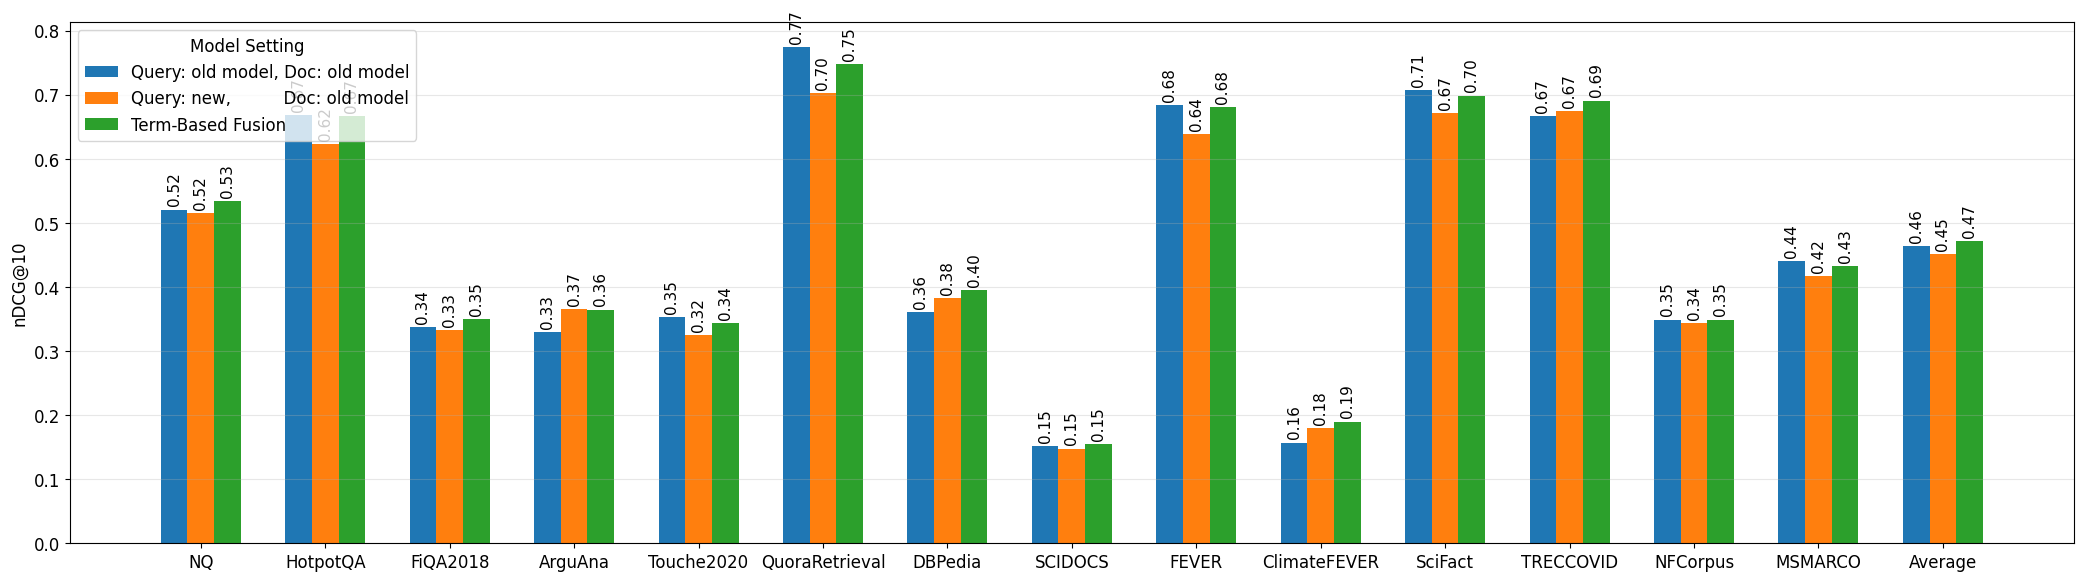

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- Data ---
data = term_based_fusion
# --- Relabel settings for readability ---
label_map = {
    'old_query_model_old_doc_model': 'Query: old model, Doc: old model',
    'new_query_model_old_doc_model': 'Query: new,          Doc: old model',
    'fusion_type_1': 'Fusion 1',
    'fusion_type_2': 'Fusion 2',
    'fusion_type_3': 'Fusion 3',
    'fusion_type_4': 'Fusion 4'
}

datasets = list(data.keys())
categories = list(next(iter(data.values())).keys())
num_cats = len(categories)

# --- Bar placement ---
bar_width = 0.15
gap = 0.25  # extra spacing between dataset groups
x = np.arange(len(datasets)) * (num_cats * bar_width + gap)

# --- Plot ---
fig, ax = plt.subplots(figsize=(21,6))

for i, category in enumerate(categories):
    values = [data[ds][category] for ds in datasets]
    ax.bar(x + i*bar_width, values, width=bar_width, label=label_map[category])

# Axis setup
ax.set_ylabel('nDCG@10')
# ax.set_title('nDCG@10 Performance Comparison')
ax.set_xticks(x + (num_cats - 1) * bar_width / 2)
ax.set_xticklabels(datasets)

# Add grid and legend
ax.grid(axis='y', alpha=0.3)
ax.legend(title='Model Setting', loc='upper left', bbox_to_anchor=(0, 1))

# Add numeric value labels on top of bars
for rect in ax.patches:
    height = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2, height + 0.006,
            f'{height:.2f}', ha='center', va='bottom', fontsize=11,rotation=90)

plt.tight_layout()
plt.show()

# significant test

In [ ]:
import json
import ir_datasets
import ir_measures
from ir_measures import *
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
def read_run(run_file_path):
    with open(run_file_path, 'r') as f:
        run = json.load(f)
    return run

old_query_model_name = "sp_tiny"
old_doc_model_name = "sp_tiny"
new_query_model_name = "sp_v3"
new_doc_model_name = "sp_v3"

dir = "/ivi/ilps/personal/jkang1/jf/lsr-bc/results/results_normal"
datasets = {
    # "TRECCOVID": "trec-covid",
    # "NFCorpus": "nfcorpus/test",
    # "NQ": "nq",
    # "HotpotQA": "hotpotqa/test",
    # "FiQA2018": "fiqa/test",
    "ArguAna": "arguana",
    "Touche2020": "webis-touche2020",
    # "CQADupstackRetrieval": "cqadupstack",
    # "QuoraRetrieval": "quora/test",
    # "DBPedia": "dbpedia-entity/test",
    # "SCIDOCS": "scidocs",
    # "FEVER": "fever/test",
    # "ClimateFEVER": "climate-fever",
    # "SciFact": "scifact/test",
    # "MSMARCO": "msmarco/dev",
}

alpha = 0.5
rank_based_fusion = {}
for path_data_name, beir_data_name in datasets.items():
    print(beir_data_name)
    if path_data_name == "CQADupstackRetrieval": 
        cqadupstack_scors = []
        for CQADupstack_name in ["AndroidRetrieval", "EnglishRetrieval", "GamingRetrieval", "GisRetrieval", "MathematicaRetrieval", "PhysicsRetrieval", "Programmers-VN", "StatsRetrieval", "TexRetrieval", "UnixRetrieval", "WebmastersRetrieval", "WordpressRetrieval"]:
            old_query_model_old_doc_model_path = f"{dir}/q_{old_query_model_name}_d_{old_doc_model_name}/CQADupstack{CQADupstack_name}_default_predictions.json"
            # new_query_model_new_doc_model_path = f"{dir}/q_{new_query_model_name}_d_{new_doc_model_name}/CQADupstack{CQADupstack_name}_default_predictions.json"
            new_query_model_old_doc_model_path = f"{dir}/q_{new_query_model_name}_d_{old_doc_model_name}/CQADupstack{CQADupstack_name}_default_predictions.json"

            old_query_model_old_doc_model_run_res = read_run(old_query_model_old_doc_model_path)
            # new_query_model_new_doc_model_run_res = read_run(new_query_model_new_doc_model_path)
            new_query_model_old_doc_model_run_res = read_run(new_query_model_old_doc_model_path)

            # fusion_run_res = fuse(
            #     runs=[convert2fusion(old_query_model_old_doc_model_run_res), convert2fusion(new_query_model_old_doc_model_run_res)],
            #     weights=[alpha, (1 - alpha)],
            # )
            qrel_name = CQADupstack_name.replace("Retrieval", "").replace("-VN", "").lower()
            qrels = ir_datasets.load(f'beir/cqadupstack/{qrel_name}').qrels
            # fusion_run_res = ir_measures.calc_aggregate([nDCG@10], qrels, fusion_run_res)
            cqadupstack_scors.append(fusion_run_res[nDCG@10])
        # print("CQADupstack Average nDCG@10:", np.mean(cqadupstack_scors))
        print(np.mean(cqadupstack_scors))
        continue
        
    old_query_model_old_doc_model_path = f"{dir}/q_{old_query_model_name}_d_{old_doc_model_name}/{path_data_name}_default_predictions.json"
    # new_query_model_new_doc_model_path = f"{dir}/q_{new_query_model_name}_d_{new_doc_model_name}/{path_data_name}_default_predictions.json"
    new_query_model_old_doc_model_path = f"{dir}/q_{new_query_model_name}_d_{old_doc_model_name}/{path_data_name}_default_predictions.json"

    old_query_model_old_doc_model_run_res = read_run(old_query_model_old_doc_model_path)
    # new_query_model_new_doc_model_run_res = read_run(new_query_model_new_doc_model_path)
    new_query_model_old_doc_model_run_res = read_run(new_query_model_old_doc_model_path)

    # fusion_run_res = fuse(
    #     runs=[convert2fusion(old_query_model_old_doc_model_run_res), convert2fusion(new_query_model_old_doc_model_run_res)],
    #     weights=[alpha, (1 - alpha)],
    # )
    qrels = ir_datasets.load(f'beir/{beir_data_name}').qrels
    old_query_model_old_doc_model_metrics = ir_measures.calc_aggregate([nDCG@10], qrels, old_query_model_old_doc_model_run_res)
    # new_query_model_new_doc_model_metrics = ir_measures.calc_aggregate([nDCG@10], qrels, new_query_model_new_doc_model_run_res)
    new_query_model_old_doc_model_metrics = ir_measures.calc_aggregate([nDCG@10], qrels, new_query_model_old_doc_model_run_res)
    # fusion_run_res = ir_measures.calc_aggregate([nDCG@10], qrels, fusion_run_res)
    # print("Dataset:", path_data_name)
    print(old_query_model_old_doc_model_metrics, "Old Query Model & Old Doc Model Results Path")
    # print(new_query_model_new_doc_model_metrics, "New Query Model & New Doc Model Results Path")
    print(new_query_model_old_doc_model_metrics, "New Query Model & Old Doc Model Results Path")
    # print(fusion_run_res, "Fusion Results Path")
    # print(fusion_run_res[nDCG@10])

arguana
{nDCG@10: 0.24466745181511435} Old Query Model & Old Doc Model Results Path
{nDCG@10: 0.275302105676601} New Query Model & Old Doc Model Results Path
webis-touche2020
{nDCG@10: 0.34156382273015845} Old Query Model & Old Doc Model Results Path
{nDCG@10: 0.3422811557500594} New Query Model & Old Doc Model Results Path


In [7]:
import json
import ir_datasets
import ir_measures
from ir_measures import *
import numpy as np

def read_run(run_file_path):
    with open(run_file_path, 'r') as f:
        return json.load(f)

def get_qrels_list(dataset_id: str):
    ds = ir_datasets.load(dataset_id)
    if hasattr(ds, "qrels_iter"):
        return list(ds.qrels_iter())
    return list(ds.qrels)

def per_query_scores(evaluator, measure, run_dict):
    out = {}
    for m in evaluator.iter_calc(run_dict):
        if m.measure == measure:
            out[m.query_id] = m.value
    return out

def paired_ttest_two_tailed_pvalue(diffs):
    """
    Paired two-tailed t-test on the paired differences.
    Returns (t_stat, p_value). Uses SciPy if present; else falls back to mpmath.
    """
    diffs = np.asarray(diffs, dtype=np.float64)
    diffs = diffs[~np.isnan(diffs)]
    n = diffs.size
    if n < 2:
        return np.nan, np.nan

    mean = diffs.mean()
    sd = diffs.std(ddof=1)
    if sd == 0.0:
        # all diffs identical -> t is infinite if mean!=0 else 0; p accordingly
        if mean == 0.0:
            return 0.0, 1.0
        return np.inf * np.sign(mean), 0.0

    t_stat = mean / (sd / np.sqrt(n))
    df = n - 1

    # Prefer SciPy if available
    try:
        from scipy import stats
        p = 2.0 * stats.t.sf(np.abs(t_stat), df)
        return float(t_stat), float(p)
    except Exception:
        # Fallback: Student-t CDF via regularized incomplete beta (mpmath)
        import mpmath as mp

        t = mp.mpf(abs(t_stat))
        v = mp.mpf(df)
        x = v / (v + t*t)  # in (0,1]
        # For t>0: CDF = 1 - 0.5 * I_x(v/2, 1/2)
        I = mp.betainc(v/2, mp.mpf('0.5'), 0, x, regularized=True)
        cdf_pos = 1 - mp.mpf('0.5') * I
        sf = 1 - cdf_pos
        p = 2 * sf
        return float(t_stat), float(p)

old_query_model_name = "sp_v3_lexical"
old_doc_model_name   = "sp_v3_lexical"
new_query_model_name = "sp_v3"
dir = "/ivi/ilps/personal/jkang1/jf/lsr-bc/results/results_normal"

datasets = {
    "TRECCOVID": "trec-covid",
    "NFCorpus": "nfcorpus/test",
    "NQ": "nq",
    "HotpotQA": "hotpotqa/test",
    "FiQA2018": "fiqa/test",
    "ArguAna": "arguana",
    "Touche2020": "webis-touche2020",
    "CQADupstackRetrieval": "cqadupstack",
    "QuoraRetrieval": "quora/test",
    "DBPedia": "dbpedia-entity/test",
    "SCIDOCS": "scidocs",
    "FEVER": "fever/test",
    "ClimateFEVER": "climate-fever",
    "SciFact": "scifact/test",
    "MSMARCO": "msmarco/dev",
}

MEAS = nDCG@10

for path_data_name, beir_data_name in datasets.items():

    if path_data_name == "CQADupstackRetrieval":
        for CQADupstack_name in [
            "AndroidRetrieval", "EnglishRetrieval", "GamingRetrieval", "GisRetrieval",
            "MathematicaRetrieval", "PhysicsRetrieval", "Programmers-VN", "StatsRetrieval",
            "TexRetrieval", "UnixRetrieval", "WebmastersRetrieval", "WordpressRetrieval"
        ]:
            old_path = f"{dir}/q_{old_query_model_name}_d_{old_doc_model_name}/CQADupstack{CQADupstack_name}_default_predictions.json"
            new_path = f"{dir}/q_{new_query_model_name}_d_{old_doc_model_name}/CQADupstack{CQADupstack_name}_default_predictions.json"

            run_old = read_run(old_path)
            run_new = read_run(new_path)

            qrel_name = CQADupstack_name.replace("Retrieval", "").replace("-VN", "").lower()
            qrels = get_qrels_list(f"beir/cqadupstack/{qrel_name}")

            evaluator = ir_measures.evaluator([MEAS], qrels)

            agg_old = evaluator.calc_aggregate(run_old)[MEAS]
            agg_new = evaluator.calc_aggregate(run_new)[MEAS]

            pq_old = per_query_scores(evaluator, MEAS, run_old)
            pq_new = per_query_scores(evaluator, MEAS, run_new)

            common_qids = sorted(set(pq_old) & set(pq_new))
            diffs = [pq_new[q] - pq_old[q] for q in common_qids]

            t_stat, p = paired_ttest_two_tailed_pvalue(diffs)

            print(
                f"CQADupstack{CQADupstack_name:>16}  "
                f"old={agg_old:.4f}  new={agg_new:.4f}  Δ={np.mean(diffs):+.4f}  "
                f"n={len(diffs):4d}  t={t_stat:+.3f}  p={p:.4g}"
            )
        continue

    old_path = f"{dir}/q_{old_query_model_name}_d_{old_doc_model_name}/{path_data_name}_default_predictions.json"
    new_path = f"{dir}/q_{new_query_model_name}_d_{old_doc_model_name}/{path_data_name}_default_predictions.json"

    run_old = read_run(old_path)
    run_new = read_run(new_path)

    qrels = get_qrels_list(f"beir/{beir_data_name}")
    evaluator = ir_measures.evaluator([MEAS], qrels)

    agg_old = evaluator.calc_aggregate(run_old)[MEAS]
    agg_new = evaluator.calc_aggregate(run_new)[MEAS]

    pq_old = per_query_scores(evaluator, MEAS, run_old)
    pq_new = per_query_scores(evaluator, MEAS, run_new)

    common_qids = sorted(set(pq_old) & set(pq_new))
    diffs = [pq_new[q] - pq_old[q] for q in common_qids]

    t_stat, p = paired_ttest_two_tailed_pvalue(diffs)

    print(
        f"{path_data_name:>20}  old={agg_old:.4f}  new={agg_new:.4f}  "
        f"Δ={np.mean(diffs):+.4f}  n={len(diffs):4d}  t={t_stat:+.3f}  p={p:.4g}"
    )

           TRECCOVID  old=0.6317  new=0.6437  Δ=+0.0120  n=  50  t=+0.469  p=0.6414
            NFCorpus  old=0.3525  new=0.3535  Δ=+0.0010  n= 323  t=+0.252  p=0.8011
                  NQ  old=0.5618  new=0.5613  Δ=-0.0005  n=3452  t=-0.141  p=0.8875
            HotpotQA  old=0.6849  new=0.6760  Δ=-0.0089  n=7405  t=-5.855  p=4.966e-09
            FiQA2018  old=0.3689  new=0.3615  Δ=-0.0074  n= 648  t=-1.320  p=0.1871
             ArguAna  old=0.3750  new=0.3693  Δ=-0.0056  n=1406  t=-1.854  p=0.06394
          Touche2020  old=0.2993  new=0.2699  Δ=-0.0293  n=  49  t=-1.779  p=0.08158
CQADupstackAndroidRetrieval  old=0.4031  new=0.4033  Δ=+0.0003  n= 699  t=+0.049  p=0.9608
CQADupstackEnglishRetrieval  old=0.4267  new=0.4092  Δ=-0.0175  n=1570  t=-4.115  p=4.077e-05
CQADupstack GamingRetrieval  old=0.5067  new=0.4999  Δ=-0.0068  n=1595  t=-1.604  p=0.109
CQADupstack    GisRetrieval  old=0.3148  new=0.3143  Δ=-0.0005  n= 885  t=-0.104  p=0.9174
CQADupstackMathematicaRetrieval  old=0.23